Figure 4b — eRegulon heatmap, Patient 1


In [1]:
import os
os.chdir("PATH_TO_DATA/Scenicplus/New_PB2")


In [2]:
import mudata
scplus_mdata = mudata.read("outs/scplusmdata.h5mu")


Requested: 52
Found: 52
Missing: []


/var/folders/96/kkldcmrj3b7c2_99mktnl80r0000gq/T/ipykernel_36386/577677691.py:241: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


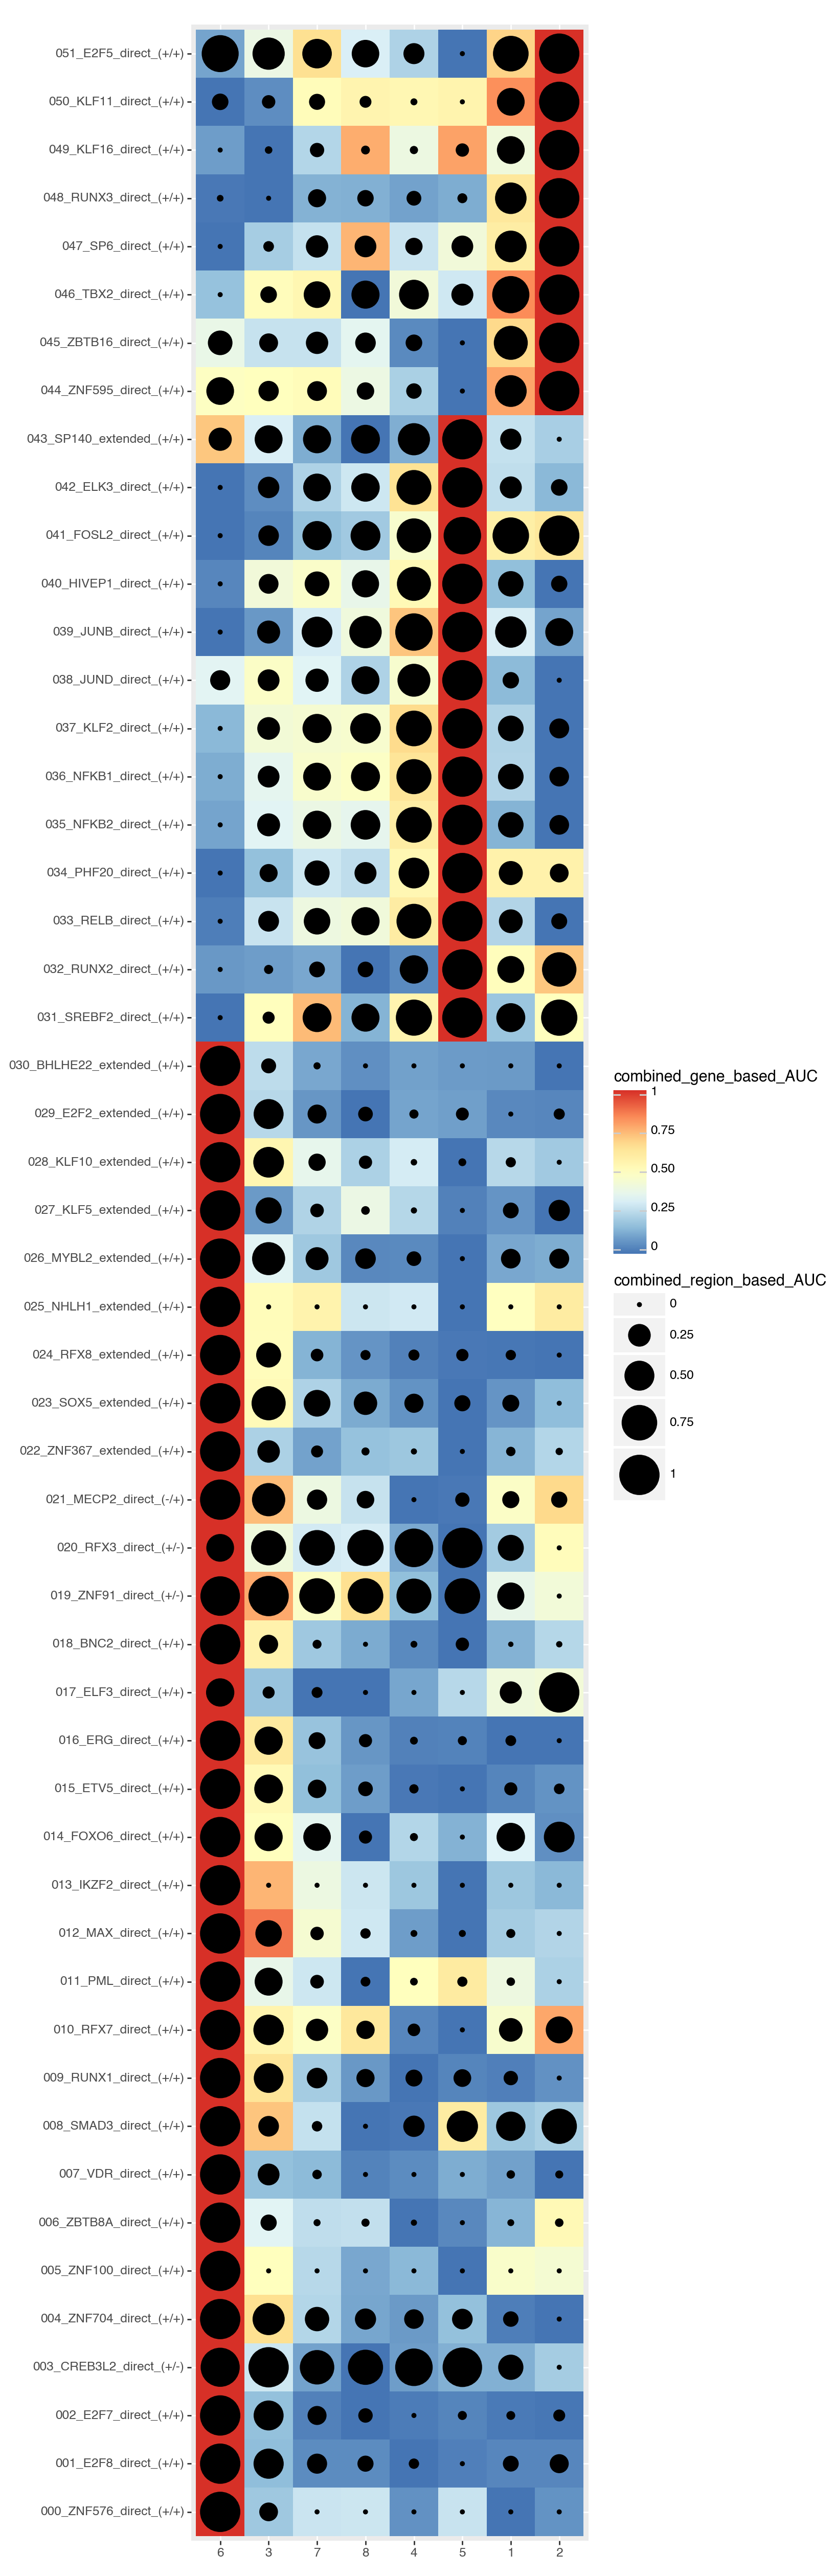

<Figure Size: (816 x 2519)>

In [12]:
import re
import pandas as pd
import anndata as ad
import plotnine
from plotnine import (
    ggplot, aes, geom_tile, geom_point,
    scale_fill_distiller, scale_size_continuous,
    theme, element_blank,
)
from scenicplus.plotting.dotplot import generate_dotplot_df

# ---- BM4 reference figsize ----
BM4_FIGSIZE = (7, 15)
BM4_NCOLS = 6
BM4_NROWS = 30
MARGIN_LEFT = 2.55
MARGIN_RIGHT = 0.95
MARGIN_TOP = 0.6
MARGIN_BOTTOM = 0.5
COL_W = (BM4_FIGSIZE[0] - MARGIN_LEFT - MARGIN_RIGHT) / BM4_NCOLS
ROW_H = (BM4_FIGSIZE[1] - MARGIN_TOP - MARGIN_BOTTOM) / BM4_NROWS

def matched_figsize(n_cols, n_rows):
    return (
        MARGIN_LEFT + MARGIN_RIGHT + COL_W * n_cols,
        MARGIN_TOP + MARGIN_BOTTOM + ROW_H * n_rows,
    )

# ---- PB2 cluster order (trajectory) ----
GROUP_ORDER = ["6", "3", "7", "8", "4", "5", "1", "2"]

DOT_SIZE_MIN = 1
DOT_SIZE_MAX = 15

# ---- PB2 eRegulons ----
requested_regulons = [
    "ZNF576_direct_(+/+)",
    "E2F8_direct_(+/+)",
    "E2F7_direct_(+/+)",
    "CREB3L2_direct_(+/-)",
    "ZNF704_direct_(+/+)",
    "ZNF100_direct_(+/+)",
    "ZBTB8A_direct_(+/+)",
    "VDR_direct_(+/+)",
    "SMAD3_direct_(+/+)",
    "RUNX1_direct_(+/+)",
    "RFX7_direct_(+/+)",
    "PML_direct_(+/+)",
    "MAX_direct_(+/+)",
    "IKZF2_direct_(+/+)",
    "FOXO6_direct_(+/+)",
    "ETV5_direct_(+/+)",
    "ERG_direct_(+/+)",
    "ELF3_direct_(+/+)",
    "BNC2_direct_(+/+)",
    "ZNF91_direct_(+/-)",
    "RFX3_direct_(+/-)",
    "MECP2_direct_(-/+)",
    "ZNF367_extended_(+/+)",
    "SOX5_extended_(+/+)",
    "RFX8_extended_(+/+)",
    "NHLH1_extended_(+/+)",
    "MYBL2_extended_(+/+)",
    "KLF5_extended_(+/+)",
    "KLF10_extended_(+/+)",
    "E2F2_extended_(+/+)",
    "BHLHE22_extended_(+/+)",
    "SREBF2_direct_(+/+)",
    "RUNX2_direct_(+/+)",
    "RELB_direct_(+/+)",
    "PHF20_direct_(+/+)",
    "NFKB2_direct_(+/+)",
    "NFKB1_direct_(+/+)",
    "KLF2_direct_(+/+)",
    "JUND_direct_(+/+)",
    "JUNB_direct_(+/+)",
    "HIVEP1_direct_(+/+)",
    "FOSL2_direct_(+/+)",
    "ELK3_direct_(+/+)",
    "SP140_extended_(+/+)",
    "ZNF595_direct_(+/+)",
    "ZBTB16_direct_(+/+)",
    "TBX2_direct_(+/+)",
    "SP6_direct_(+/+)",
    "RUNX3_direct_(+/+)",
    "KLF16_direct_(+/+)",
    "KLF11_direct_(+/+)",
    "E2F5_direct_(+/+)",
]

def parse_requested(x):
    m = re.match(r"^(.+?)_(direct|extended)_\(([+-]/[+-])\)$", x)
    if m is None:
        return None
    return m.group(1), m.group(2), m.group(3)

def parse_real_auc_name(x):
    m = re.match(r"^(.+?)_(direct|extended)_([+-]/[+-])_\((\d+)([gr])\)$", str(x))
    if m is None:
        return None
    tf, mode, sign, n, kind = m.groups()
    return tf, mode, sign, int(n), kind

gene_auc_raw = pd.concat(
    [
        scplus_mdata.mod["direct_gene_based_AUC"].to_df(),
        scplus_mdata.mod["extended_gene_based_AUC"].to_df(),
    ],
    axis=1,
)

region_auc_raw = pd.concat(
    [
        scplus_mdata.mod["direct_region_based_AUC"].to_df(),
        scplus_mdata.mod["extended_region_based_AUC"].to_df(),
    ],
    axis=1,
)

gene_auc_raw = gene_auc_raw.loc[:, ~gene_auc_raw.columns.duplicated()].copy()
region_auc_raw = region_auc_raw.loc[:, ~region_auc_raw.columns.duplicated()].copy()

gene_lookup = {}
for col in gene_auc_raw.columns:
    parsed = parse_real_auc_name(col)
    if parsed is None:
        continue
    tf, mode, sign, n, kind = parsed
    if kind != "g":
        continue
    key = (tf, mode, sign)
    if key not in gene_lookup or n > gene_lookup[key][1]:
        gene_lookup[key] = (col, n)

region_lookup = {}
for col in region_auc_raw.columns:
    parsed = parse_real_auc_name(col)
    if parsed is None:
        continue
    tf, mode, sign, n, kind = parsed
    if kind != "r":
        continue
    key = (tf, mode, sign)
    if key not in region_lookup or n > region_lookup[key][1]:
        region_lookup[key] = (col, n)

new_gene_auc = pd.DataFrame(index=gene_auc_raw.index)
new_region_auc = pd.DataFrame(index=region_auc_raw.index)
meta_rows = []
missing = []

for i, req in enumerate(requested_regulons):
    parsed = parse_requested(req)

    if parsed is None:
        missing.append(req)
        continue

    tf, mode, sign = parsed
    key = (tf, mode, sign)

    if key not in gene_lookup or key not in region_lookup:
        missing.append(req)
        continue

    gene_col = gene_lookup[key][0]
    region_col = region_lookup[key][0]

    clean_name = f"{i:03d}_{req}"
    gene_feature = f"{clean_name}_gene"
    region_feature = f"{clean_name}_region"

    new_gene_auc[gene_feature] = gene_auc_raw[gene_col]
    new_region_auc[region_feature] = region_auc_raw[region_col]

    meta_rows.append({
        "Gene_signature_name": gene_feature,
        "Region_signature_name": region_feature,
        "eRegulon_name": clean_name,
        "original_gene_signature": gene_col,
        "original_region_signature": region_col,
    })

meta_final = pd.DataFrame(
    meta_rows,
    columns=[
        "Gene_signature_name",
        "Region_signature_name",
        "eRegulon_name",
        "original_gene_signature",
        "original_region_signature",
    ],
)

print("Requested:", len(requested_regulons))
print("Found:", meta_final.shape[0])
print("Missing:", missing)

if meta_final.empty:
    raise ValueError("No regulons were matched. Check the real AUC var names and signs.")

scplus_mdata.mod["combined_gene_based_AUC"] = ad.AnnData(new_gene_auc)
scplus_mdata.mod["combined_region_based_AUC"] = ad.AnnData(new_region_auc)

scplus_mdata.uns["combined_e_regulon_metadata"] = meta_final[
    ["Gene_signature_name", "Region_signature_name", "eRegulon_name"]
].copy()

GROUP_VAR = "scRNA_counts:celltype"
COLOR_MOD = "combined_gene_based_AUC"
SIZE_MOD = "combined_region_based_AUC"
META_KEY = "combined_e_regulon_metadata"

size_matrix = scplus_mdata.mod[SIZE_MOD].to_df()
color_matrix = scplus_mdata.mod[COLOR_MOD].to_df()
group_by = scplus_mdata.obs[GROUP_VAR].tolist()

size_features, color_features, feature_names = scplus_mdata.uns[META_KEY][
    ["Region_signature_name", "Gene_signature_name", "eRegulon_name"]
].drop_duplicates().values.T

plotting_df = generate_dotplot_df(
    size_matrix=size_matrix,
    color_matrix=color_matrix,
    group_by=group_by,
    size_features=size_features,
    color_features=color_features,
    feature_names=feature_names,
    scale_size_matrix=True,
    scale_color_matrix=True,
    group_name=GROUP_VAR,
    size_name=SIZE_MOD,
    color_name=COLOR_MOD,
    feature_name="eRegulon_name",
)

plotting_df[GROUP_VAR] = pd.Categorical(
    plotting_df[GROUP_VAR], categories=GROUP_ORDER, ordered=True
)

tmp = plotting_df[[GROUP_VAR, "eRegulon_name", COLOR_MOD]].pivot_table(
    index=GROUP_VAR, columns="eRegulon_name"
).fillna(0)[COLOR_MOD]

if GROUP_ORDER is not None:
    tmp = tmp.loc[GROUP_ORDER]

idx_max = tmp.idxmax(axis=0)
order = pd.concat([
    idx_max[idx_max == x]
    for x in tmp.index.tolist()
    if (plotting_df[GROUP_VAR] == x).any()
]).index.tolist()

plotting_df["eRegulon_name"] = pd.Categorical(
    plotting_df["eRegulon_name"], categories=order, ordered=True
)

plotnine.options.figure_size = matched_figsize(len(GROUP_ORDER), len(meta_final))

p = (
    ggplot(plotting_df, aes(GROUP_VAR, "eRegulon_name"))
    + geom_tile(aes(fill=COLOR_MOD))
    + scale_fill_distiller(type="div", palette="RdYlBu")
    + geom_point(aes(size=SIZE_MOD), colour="black")
    + scale_size_continuous(
        range=(DOT_SIZE_MIN, DOT_SIZE_MAX),
        limits=(0, 1),
        breaks=[0, 0.25, 0.5, 0.75, 1],
    )
    + theme(
        axis_title_x=element_blank(),
        axis_title_y=element_blank(),
    )
)

p
